### Imports

In [1]:
import random

import numpy as np
import pandas as pd
import torch
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import RobertaForSequenceClassification, RobertaTokenizer

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

In [4]:
class SQLInjectionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [5]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.from_numpy(logits), dim=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [6]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", save_as=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malicious'],
                yticklabels=['Benign', 'Malicious'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    if save_as:
        plt.savefig(save_as, dpi=300, bbox_inches='tight')
    plt.show()
    return cm

In [7]:
df1 = pd.read_csv('data/SQL_injection_Dataset.csv')
df2 = pd.read_csv('data/clean_sql_dataset.csv')

In [8]:
class_counts = df1['Label'].value_counts()
print(f"DF1 Original class distribution:\n{class_counts}")

class_counts = df2['Label'].value_counts()
print(f"DF2 Original class distribution:\n{class_counts}")

DF1 Original class distribution:
Label
0    19537
1    11382
Name: count, dtype: int64
DF2 Original class distribution:
Label
1    77750
0    70576
Name: count, dtype: int64


In [9]:
_, df1_test_texts, _, df1_test_labels = train_test_split(
    df1['Query'].tolist(), df1['Label'].tolist(), test_size=0.25, random_state=SEED
)

df2_test_texts, df2_test_labels = df2['Query'].tolist(), df2['Label'].tolist()

In [10]:
print(len(df1_test_texts), len(df1_test_labels))
print(len(df2_test_texts), len(df2_test_labels))

7730 7730
148326 148326


### Load fine tuned codebert model

In [11]:
model = RobertaForSequenceClassification.from_pretrained("fine_tuned_codebert_model")
tokenizer = RobertaTokenizer.from_pretrained("fine_tuned_codebert_model")

model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

### Load hardened codebert model

In [12]:
model_v2 = RobertaForSequenceClassification.from_pretrained("hardened_codebert_model")
tokenizer_v2 = RobertaTokenizer.from_pretrained("hardened_codebert_model")

model_v2.to(device)
model_v2.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

### Tokenize test sets

In [13]:
df1_encodings = tokenizer(df1_test_texts, truncation=True, padding=True, max_length=128)
df2_encodings = tokenizer_v2(df2_test_texts, truncation=True, padding=True, max_length=128) # TODO v1 or v2

In [14]:
df1_test = SQLInjectionDataset(df1_encodings, df1_test_labels)
df2_test = SQLInjectionDataset(df2_encodings, df2_test_labels)

In [15]:
seed_value = 42
g = torch.Generator()
g.manual_seed(seed_value)

df1_loader = DataLoader(
    df1_test,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

df2_loader = DataLoader(
    df2_test,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    # generator=g,
)

### Evaluate models on test sets

In [16]:
print(f"Evaluating on device: {device}")
results = {}
for_plotting = {}
raw_data = {}

models = [
    ("model", model),
    ("model_v2", model_v2),
]

loaders = [
    ("df1_loader", df1_loader),
    ("df2_loader", df2_loader),
]

for model_name, model_obj in models:
    for loader_name, loader_obj in loaders:
        ident = f"{model_name} - {loader_name}"
        # if "df1_loader" not in ident:
        #     continue

        print(f"Evaluating {ident}...")
        all_logits = []
        all_labels = []

        with torch.no_grad():
            # limit = max(1, int(0.1 * len(loader_obj)))
            # g.manual_seed(42)

            for batch in tqdm(loader_obj, desc=ident, leave=False, total=len(loader_obj)):
            # for i, batch in tqdm(loader_obj, desc=ident, leave=False, total=limit):
                # if i % 10 == 0:
                #     print(f"  Processed {i}/{len(loader_obj)} batches...")
                # if i >= limit:
                #     break

                inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
                labels = batch["labels"].to(device)

                outputs = model_obj(**inputs)
                logits = outputs.logits

                all_logits.append(logits.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        logits = np.concatenate(all_logits, axis=0)
        labels = np.concatenate(all_labels, axis=0)

        eval_results = compute_metrics((logits, labels))

        results[ident] = eval_results

        for_plotting[ident] = [labels, np.argmax(logits, axis=-1)]

        raw_data[ident] = (logits, labels)

Evaluating on device: mps
Evaluating model - df1_loader...


model - df1_loader:   0%|          | 0/242 [00:00<?, ?it/s]

Evaluating model - df2_loader...


model - df2_loader:   0%|          | 0/9271 [00:00<?, ?it/s]

Evaluating model_v2 - df1_loader...


model_v2 - df1_loader:   0%|          | 0/242 [00:00<?, ?it/s]

Evaluating model_v2 - df2_loader...


model_v2 - df2_loader:   0%|          | 0/9271 [00:00<?, ?it/s]

In [17]:
# save for_plotting and results to file
import pickle
with open("for_plotting.pkl", "wb") as f:
    pickle.dump(for_plotting, f)

with open("results.pkl", "wb") as f:
    pickle.dump(results, f)

with open("raw_data.pkl", "wb") as f:
    pickle.dump(raw_data, f)

In [18]:
# load for_plotting and results from file
import pickle
with open("for_plotting.pkl", "rb") as f:
    for_plotting = pickle.load(f)

with open("results.pkl", "rb") as f:
    results = pickle.load(f)

with open("raw_data.pkl", "rb") as f:
    raw_data = pickle.load(f)

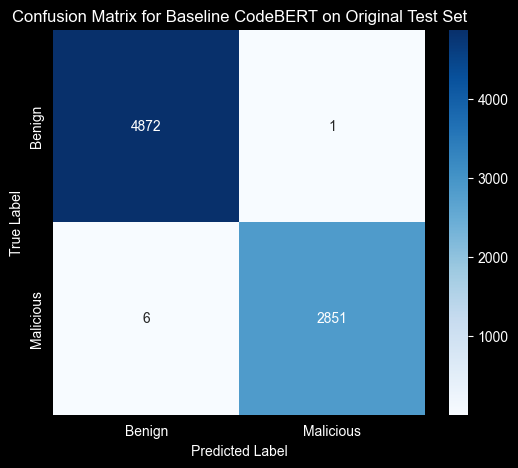

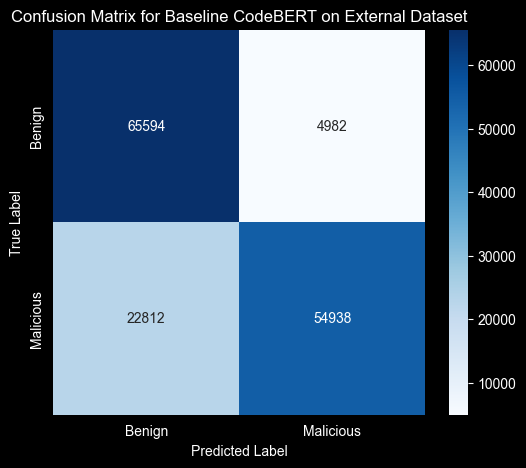

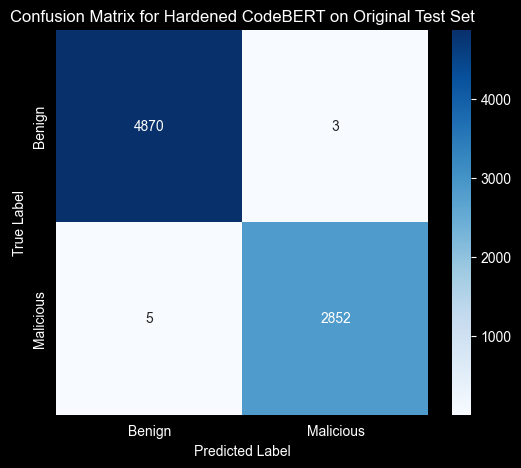

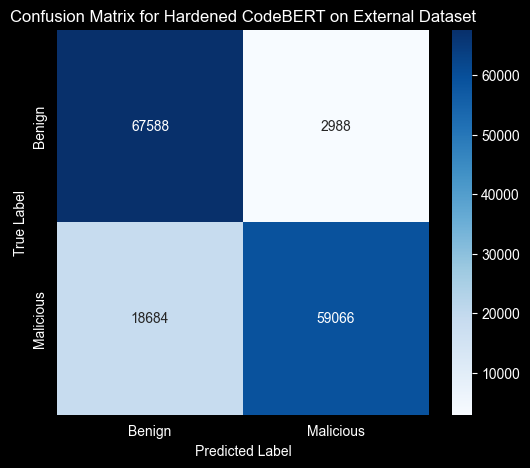

In [31]:
# plot all confusion matrices
nice_ident = {
    "model - df1_loader": "Baseline CodeBERT on Original Test Set",
    "model - df2_loader": "Baseline CodeBERT on External Dataset",
    "model_v2 - df1_loader": "Hardened CodeBERT on Original Test Set",
    "model_v2 - df2_loader": "Hardened CodeBERT on External Dataset",
}
for ident, (labels, preds) in for_plotting.items():
    plot_confusion_matrix(labels, preds, title=f"Confusion Matrix for {nice_ident[ident]}")

In [25]:
from sklearn.metrics import roc_auc_score
from scipy.special import softmax

def add_auc_to_results(raw_data, results):
    for ident, (logits, labels) in raw_data.items():
        probs = softmax(logits, axis=-1)
        auc = roc_auc_score(labels, probs[:, 1])

        results[ident]["auc_roc"] = float(auc)

add_auc_to_results(raw_data, results)

In [26]:
for ident, metrics in results.items():
    print(f"Results for {ident}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

Results for model - df1_loader:
  accuracy: 0.9991
  f1: 0.9988
  precision: 0.9996
  recall: 0.9979
  auc_roc: 0.9997
Results for model - df2_loader:
  accuracy: 0.8126
  f1: 0.7981
  precision: 0.9169
  recall: 0.7066
  auc_roc: 0.8785
Results for model_v2 - df1_loader:
  accuracy: 0.9990
  f1: 0.9986
  precision: 0.9989
  recall: 0.9982
  auc_roc: 0.9997
Results for model_v2 - df2_loader:
  accuracy: 0.8539
  f1: 0.8450
  precision: 0.9518
  recall: 0.7597
  auc_roc: 0.8715


<Figure size 1200x600 with 0 Axes>

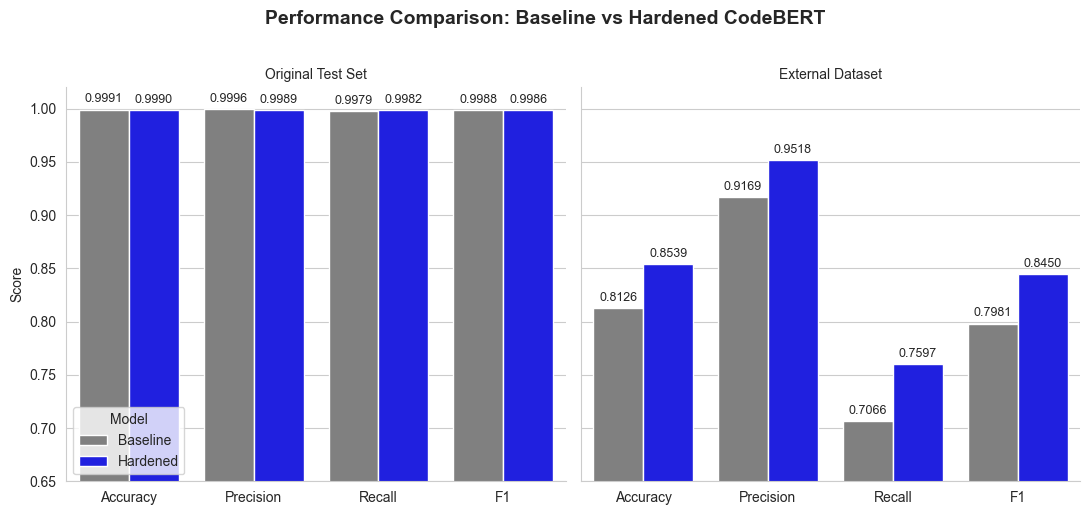

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data from your existing 'results' variable
data = []
for model_name, metrics in results.items():
    model_type = "Baseline" if "model - df" in model_name else "Hardened"
    dataset = "Original Test Set" if "df1" in model_name else "External Dataset"

    for metric in ["accuracy", "precision", "recall", "f1"]:
        data.append({
            "Dataset": dataset,
            "Model": model_type,
            "Metric": metric.capitalize(),
            "Value": metrics[metric]
        })

df_plot = pd.DataFrame(data)

# Create the figure
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

g = sns.catplot(
    data=df_plot,
    x="Metric",
    y="Value",
    hue="Model",
    col="Dataset",
    kind="bar",
    height=5,
    aspect=1.1,
    palette=["grey", "blue"],   # Red = Baseline, Green = Hardened
    legend_out=False
)

# Formatting
g.set_axis_labels("", "Score")
g.set_titles("{col_name}")
g.set(ylim=(0.65, 1.02))

# Add value labels on bars
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)

plt.suptitle("Performance Comparison: Baseline vs Hardened CodeBERT",
             y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()

# Save figure
plt.savefig("figures/figure3_metric_comparison.png", dpi=600, bbox_inches="tight")
plt.show()